<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 157 &middot; Communicating Results &middot; Report 2 of 3</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Analysis for the Experiment Readout: A/B Test Results</div>
  <div style="font-size:15px;color:#ffe4e6;max-width:760px;line-height:1.6">This notebook runs the A/B test analysis and builds the one honest chart. It stops at the evidence; the decision memo itself is a separate, human-authored Word document a statistician writes for the Growth team. Download it from the chapter.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
# A clean house style for report-ready figures: no chartjunk, strong titles, muted grid.
mpl.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,
    "axes.titlelocation":"left","axes.titlepad":10})
ROSE, INK, MUT, GR, RD = "#be123c", "#1a2138", "#64748b", "#16a34a", "#dc2626"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "communicating-insights--company-data.xlsx"
def load(sheet):
    try: return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

## Step 1 &middot; Analyze the experiment
Two versions of a checkout, split evenly. Compute the conversion rates, the lift, and, crucially, the statistical evidence: a two-proportion test and a confidence interval on the difference.

In [2]:
ab = load("ABTest")
vis = ab.visitors.values; conv = ab.conversions.values
rA, rB = conv[0]/vis[0], conv[1]/vis[1]
abs_lift, rel_lift = rB-rA, (rB-rA)/rA
z, p = proportions_ztest([conv[1], conv[0]], [vis[1], vis[0]])
ci_low, ci_high = confint_proportions_2indep(conv[1], vis[1], conv[0], vis[0])
print(f"A {rA:.2%}  B {rB:.2%}  | abs lift {abs_lift:+.2%}pts  rel {rel_lift:+.0%}")
print(f"z {z:.2f}  p {p:.4f}  | 95% CI on difference [{ci_low:+.2%}, {ci_high:+.2%}]")
decision = "SHIP the new checkout" if (p < 0.05 and abs_lift > 0) else "DO NOT ship; keep the control"
print("decision:", decision)

A 8.10%  B 9.40%  | abs lift +1.30%pts  rel +16%
z 2.52  p 0.0117  | 95% CI on difference [+0.29%, +2.31%]
decision: SHIP the new checkout


## Step 2 &middot; One honest chart
A bar of the two rates with a confidence interval on each. Zero baseline, so the reader sees the true size of the effect, not an inflated one.

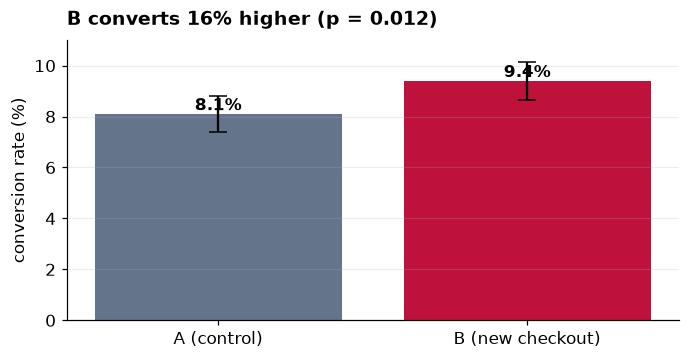

In [3]:
from statsmodels.stats.proportion import proportion_confint
lo = [proportion_confint(conv[i], vis[i])[0]*100 for i in range(2)]
hi = [proportion_confint(conv[i], vis[i])[1]*100 for i in range(2)]
rates = [rA*100, rB*100]
fig_ab, ax = plt.subplots(figsize=(6.4, 3.4))
bars = ax.bar(["A (control)","B (new checkout)"], rates, color=[MUT, ROSE],
              yerr=[np.subtract(rates,lo), np.subtract(hi,rates)], capsize=6)
for b,v in zip(bars, rates): ax.text(b.get_x()+b.get_width()/2, v+0.15, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylim(0, 11); ax.set_ylabel("conversion rate (%)")
ax.set_title(f"B converts {rel_lift:.0%} higher (p = {p:.3f})"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## Step 3 &middot; The results table for the memo
The chart above plus this small table are the evidence. The statistician writing the memo pastes the chart in and reports the numbers below in plain language, uncertainty included.

In [4]:
res = pd.DataFrame({"Group":["A (control)","B (new checkout)"],
                   "Visitors":[f"{vis[0]:,}", f"{vis[1]:,}"],
                   "Conversions":[f"{conv[0]:,}", f"{conv[1]:,}"],
                   "Rate":[f"{rA:.1%}", f"{rB:.1%}"]})
print(res.to_string(index=False))
print(f"\nrelative lift {rel_lift:+.0%} | z {z:.2f} | p {p:.3f} | 95% CI on difference [{ci_low:+.2%}, {ci_high:+.2%}]")
res

           Group Visitors Conversions Rate
     A (control)    6,000         486 8.1%
B (new checkout)    6,000         564 9.4%

relative lift +16% | z 2.52 | p 0.012 | 95% CI on difference [+0.29%, +2.31%]


,Group,Visitors,Conversions,Rate
0,A (control),"6,000",486,8.1%
1,B (new checkout),"6,000",564,9.4%


### From analysis to report
This notebook is the **analysis**: the rates, the significance test, the confidence interval, and the one honest chart. The finished **decision memo** is a separate, human-authored Word document, a statistician writing for the Growth team, who puts the recommendation in the first line, explains the p-value and the interval in everyday words, and is candid about how much we do and do not know. Download it from the chapter and compare it to this raw output.